In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
from _notebook_init import DATA_PROCESSED

from weather_markov.models.full_graph import FullGraphMarkovPredictor
from weather_markov.preprocessing.discretizer import TemperatureDiscretizer
from weather_markov.visualization.plots import (plot_graph_network,
                                                plot_prediction_distribution,
                                                plot_transition_matrix)

### test on previous years

In [3]:
decade_df = pd.read_csv(DATA_PROCESSED / "decades.csv")

disc = TemperatureDiscretizer.from_equal_width(n_bins=10, t_min=-15, t_max=20)

train_years = range(2000, 2024)
test_years = range(2024, 2026)

train_df = decade_df[decade_df["year"].isin(train_years)]
test_df = decade_df[decade_df["year"].isin(test_years)]

disc.fit(train_df["avg_temperature"])
model = FullGraphMarkovPredictor(disc).fit(train_df)

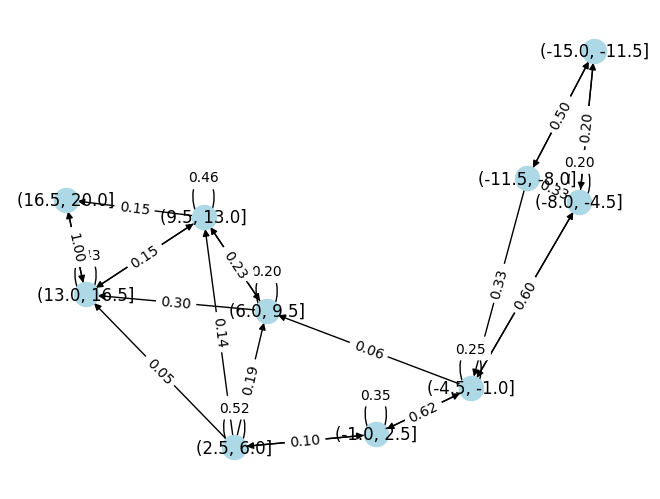

In [4]:
plot_graph_network(model.shared_graph)

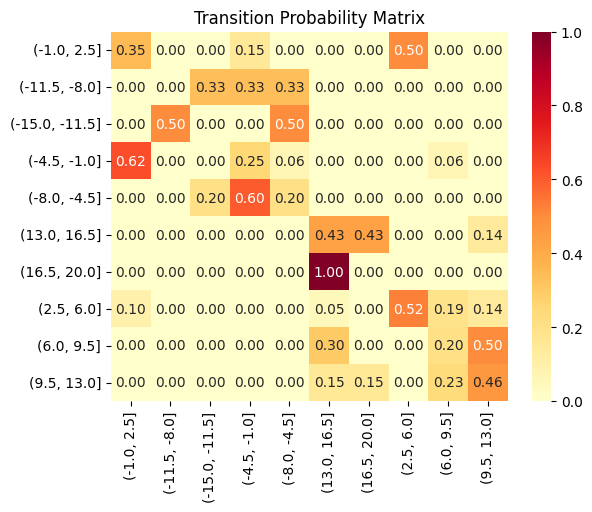

In [5]:
plot_transition_matrix(model.shared_graph)

In [6]:
results = []

for test_year in test_years:
    feb_temp = (
        test_df[(test_df["year"] == test_year) & (test_df["month"] == 2)][
            "avg_temperature"
        ]
    ).iloc[0]
    may_temp = test_df[(test_df["year"] == test_year) & (test_df["month"] == 5)][
        "avg_temperature"
    ].mean()

    pred_dist = model.predict(disc.transform(feb_temp).iloc[0])
    pred_label = model.predict_label(disc.transform(feb_temp).iloc[0])
    true_label = disc.transform(pd.Series([may_temp])).iloc[0]

    results.append(
        {
            "year": test_year,
            "pred": pred_label,
            "true": true_label,
            "correct": pred_label == true_label,
            "dist": pred_dist,
        }
    )

In [7]:
results_df = pd.DataFrame(results)
results_df

,year,pred,true,correct,dist
0,2024,"(13.0, 16.5]","(9.5, 13.0]",False,"{'(-8.0, -4.5]': 0.007378926350185263, '(-15.0..."
1,2025,"(13.0, 16.5]","(9.5, 13.0]",False,"{'(-4.5, -1.0]': 0.013349952513867953, '(-1.0,..."


### 2026 prediction

In [8]:
disc = TemperatureDiscretizer.from_equal_width(n_bins=10, t_min=-20, t_max=25)

train_years = range(2000, 2026)

train_df = decade_df[decade_df["year"].isin(train_years)]

disc.fit(train_df["avg_temperature"])
model = FullGraphMarkovPredictor(disc).fit(train_df)

In [9]:
current_year = 2026

feb_temp = (
    decade_df[(decade_df["year"] == current_year) & (decade_df["month"] == 2)][
        "avg_temperature"
    ]
).iloc[0]

pred_dist = model.predict(disc.transform(feb_temp).iloc[0])
pred_label = model.predict_label(disc.transform(feb_temp).iloc[0])

pred_label

'(11.5, 16.0]'

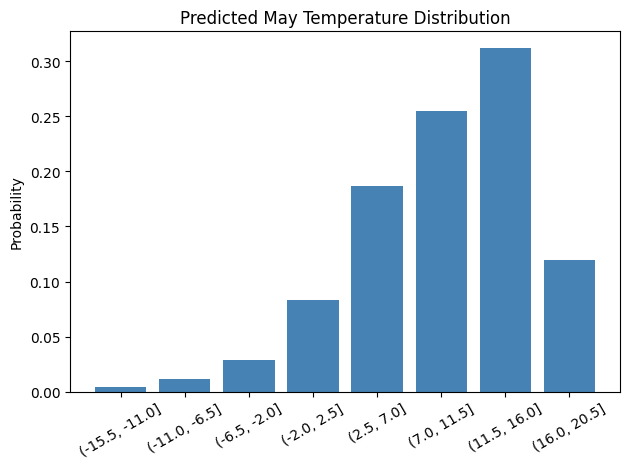

In [11]:
plot_prediction_distribution(pred_dist)